# Notebook 01 — Activation Scale Calibration for Qwen2.5-Coder

This is the foundation of every other notebook in the project. SmoothQuant needs, for each `nn.Linear` in the model, a per-input-channel estimate of how large the activations get. We compute this by running the model on a calibration corpus and tracking the per-channel absolute maximum.

The output is a dict `{module_path: torch.Tensor of shape [in_features]}` saved to `act_scales/qwen25-coder-<size>.pt`. Every downstream notebook loads this file.

## What this notebook does

1. Loads Qwen2.5-Coder-Instruct (7B or 14B) in bf16
2. Hooks every `nn.Linear` to record per-channel activation absmax
3. Feeds 512 samples (512 tokens each) from the Pile validation set
4. Saves the resulting scales dict
5. Sanity-checks the output: prints the most outlier-heavy channels and plots the distribution

## Runtime

- **7B on L4 or A100**: ~8 min
- **14B on A100 40GB**: ~15 min
- 14B on L4: will OOM because bf16 weights alone need ~28 GB

## Why calibrate on Pile (not on code)?

The SmoothQuant paper uses 512 random sentences from the Pile validation split. We use the same dataset to stay faithful to the paper. If you want to experiment with code-specific calibration (e.g., `bigcode/the-stack-smol`), change `DATASET_NAME` below — this is a good ablation for the project's stretch goals.

## Prerequisites

- Repo cloned with `external/smoothquant` subdirectory (`pip install -e external/smoothquant` is NOT strictly needed — we only import our own adapted code — but install it anyway for the upstream reference utilities).
- HuggingFace login: `huggingface-cli login`
- GPU with enough VRAM: 16+ GB for 7B bf16, 32+ GB for 14B bf16

## Section 1 — Setup

In [1]:
# ============================================================
# Idempotent pinned-install cell.
# First run on a fresh pod: installs the stack (~4 min), prints
#     "RESTART THE KERNEL NOW" — do it, then re-run this cell.
# Subsequent runs: verifies versions, no-op in ~3 seconds.
# ============================================================
import importlib.metadata as _md
import subprocess, sys
import os
os.environ['HF_HUB_DISABLE_XET'] = '1'
os.environ['HF_XET_DISABLE'] = '1'  # belt and suspenders

_pinned = [
    ('torch',              '2.9.1',  'exact'),
    ('typing_extensions',  '4.13',   'floor'),
    ('compressed-tensors', '0.13.0', 'exact'),
    ('transformers',       '4.57.3', 'exact'),
    ('llmcompressor',      '0.9.0',  'exact'),
]

def _tup(s):
    return tuple(int(x) for x in s.split('+')[0].split('.')[:3] if x.isdigit())

def _ok(pkg, want, mode):
    try:
        have = _md.version(pkg)
    except _md.PackageNotFoundError:
        return False, '(missing)'
    if mode == 'exact':
        return have == want, have
    if mode == 'floor':
        return _tup(have) >= _tup(want), have
    raise ValueError(mode)

status = [(pkg, want, mode, *_ok(pkg, want, mode)) for pkg, want, mode in _pinned]
all_ok = all(ok for *_, ok, _ in status)

print(f'{"package":<22s} {"installed":<14s} {"pinned":<14s} status')
print('-' * 64)
for pkg, want, mode, ok, have in status:
    tag = 'OK' if ok else 'MISMATCH'
    w = f'>={want}' if mode == 'floor' else want
    print(f'{pkg:<22s} {have:<14s} {w:<14s} {tag}')

if all_ok:
    print('\nEnvironment already pinned — skipping install.')
else:
    print('\nInstalling pinned stack (~4 min)...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'uninstall', '-y', '-q',
        'torch', 'torchvision', 'torchaudio',
        'nvidia-cuda-nvrtc-cu12', 'nvidia-cuda-runtime-cu12', 'nvidia-cudnn-cu12',
        'nvidia-cublas-cu12', 'nvidia-cufft-cu12', 'nvidia-curand-cu12',
        'nvidia-cusolver-cu12', 'nvidia-cusparse-cu12', 'nvidia-cusparselt-cu12',
        'nvidia-nccl-cu12', 'nvidia-nvtx-cu12', 'nvidia-nvjitlink-cu12',
        'llmcompressor', 'compressed-tensors', 'transformers', 'typing_extensions',
    ])
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
        'torch==2.9.1',
        'typing_extensions>=4.13',
        'compressed-tensors==0.13.0',
        'transformers==4.57.3',
        'llmcompressor==0.9.0',
        'accelerate', 'safetensors', 'datasets', 'tqdm',
        'matplotlib', 'pandas', 'vllm',
        'evalplus', 'bigcodebench',
    ])
    print()
    print('=' * 60)
    print('INSTALL COMPLETE — RESTART THE KERNEL NOW, then re-run this cell.')
    print('=' * 60)

package                installed      pinned         status
----------------------------------------------------------------
torch                  2.9.1          2.9.1          OK
typing_extensions      4.15.0         >=4.13         OK
compressed-tensors     0.13.0         0.13.0         OK
transformers           4.57.3         4.57.3         OK
llmcompressor          0.9.0          0.9.0          OK

Environment already pinned — skipping install.


In [2]:
# Runpod / bare-pod setup. Assumes the repo lives at /workspace/qwen-smoothquant-project
# and that HF cache is on a persistent volume at /workspace/hf-cache. If you're
# running elsewhere, change PROJECT_ROOT below.
import os, sys

PROJECT_ROOT = '/workspace/qwen-smoothquant-project'
assert os.path.exists(PROJECT_ROOT), (
    f'Project not found at {PROJECT_ROOT}. Clone the repo there or edit PROJECT_ROOT.'
)
os.chdir(PROJECT_ROOT)
assert os.path.exists('src/qwen_smooth.py'), 'src/ missing — are you in the repo root?'

os.environ.setdefault('HF_HOME', '/workspace/hf-cache')
os.makedirs(os.environ['HF_HOME'], exist_ok=True)


# Output directories (act_scales is where this notebook writes; results/plots
# is used by the sanity-check plot in Section 4)
for d in ['act_scales', 'results', 'results/plots']:
    os.makedirs(d, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'HF_HOME:      {os.environ["HF_HOME"]}')


Project root: /workspace/qwen-smoothquant-project
HF_HOME:      /workspace/hf-cache


In [3]:
# Make src/ importable
import sys, os
repo_root = os.path.abspath('.')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from src.calibrate import get_act_scales, save_act_scales


In [4]:
# ============================================================
# CONFIG — only this block changes when switching 7B ↔ 14B.
# ============================================================
MODEL_SIZE   = '7B'                                          # '7B' or '14B'
SIZE         = MODEL_SIZE.lower()                            # '7b' or '14b'
MODEL_ID     = f'Qwen/Qwen2.5-Coder-{MODEL_SIZE}-Instruct'
DATASET_NAME = 'mit-han-lab/pile-val-backup'                 # same as SmoothQuant paper
NUM_SAMPLES  = 512
SEQ_LEN      = 512
OUT_PATH     = f'act_scales/qwen25-coder-{SIZE}.pt'

print(f'Model:    {MODEL_ID}')
print(f'Dataset:  {DATASET_NAME}')
print(f'Samples:  {NUM_SAMPLES} x {SEQ_LEN} tokens')
print(f'Output:   {OUT_PATH}')


Model:    Qwen/Qwen2.5-Coder-7B-Instruct
Dataset:  mit-han-lab/pile-val-backup
Samples:  512 x 512 tokens
Output:   act_scales/qwen25-coder-7b.pt


In [5]:
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv,noheader

NVIDIA A100 80GB PCIe, 81920 MiB, 0 MiB


## Section 2 — Load the model

Strictly bf16. No quantization at calibration time — we need the true activation statistics.

In [6]:
import os
os.environ['HF_HUB_DISABLE_XET'] = '1'

In [7]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

print(f'Loading {MODEL_ID} in bf16 ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,        # new API; was torch_dtype= (deprecated)
    device_map='auto',
)
model.eval()
print('Ready.')


Loading Qwen/Qwen2.5-Coder-7B-Instruct in bf16 ...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00004.safetensors:   0%|          | 0.00/4.88G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/4.93G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Ready.


In [8]:
# Log the model architecture — this is useful to have printed in your writeup.
# Note that Qwen2Attention has bias on q/k/v/ proj (unlike Llama) and uses GQA.
cfg = model.config
total_params = sum(p.numel() for p in model.parameters())
print(f'{MODEL_ID}')
print(f'  hidden_size         : {cfg.hidden_size}')
print(f'  intermediate_size   : {cfg.intermediate_size}')
print(f'  num_hidden_layers   : {cfg.num_hidden_layers}')
print(f'  num_attention_heads : {cfg.num_attention_heads}')
print(f'  num_key_value_heads : {cfg.num_key_value_heads}  (GQA ratio: {cfg.num_attention_heads // cfg.num_key_value_heads}x)')
print(f'  vocab_size          : {cfg.vocab_size}')
print(f'  total parameters    : {total_params/1e9:.2f}B')

Qwen/Qwen2.5-Coder-7B-Instruct
  hidden_size         : 3584
  intermediate_size   : 18944
  num_hidden_layers   : 28
  num_attention_heads : 28
  num_key_value_heads : 4  (GQA ratio: 7x)
  vocab_size          : 152064
  total parameters    : 7.62B


## Section 3 — Run calibration

`get_act_scales` hooks every `nn.Linear` in the model and records `|input|.max(dim=-1)` — the per-channel absolute maximum over the calibration corpus. This is exactly what the SmoothQuant paper does (see `smoothquant/calibration.py` in the upstream repo).

In [9]:
act_scales = get_act_scales(
    model=model,
    tokenizer=tokenizer,
    dataset_name=DATASET_NAME,
    num_samples=NUM_SAMPLES,
    seq_len=SEQ_LEN,
)
print(f'Collected scales for {len(act_scales)} Linear modules')

README.md:   0%|          | 0.00/167 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


val.jsonl.zst:   0%|          | 0.00/471M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/214670 [00:00<?, ? examples/s]

Calibrating: 100%|██████████| 512/512 [00:39<00:00, 12.91it/s]

Collected scales for 197 Linear modules


In [10]:
# Save to Drive/disk before we look at anything — calibration is the most
# expensive step and we don't want to redo it.
os.makedirs('act_scales', exist_ok=True)
save_act_scales(act_scales, OUT_PATH)

Saved 197 act_scales to act_scales/qwen25-coder-7b.pt


## Section 4 — Sanity-check the scales

Three quick checks. If any of these look wrong, don't proceed to quantization until you've understood why.

1. **We have scales for the expected Linears.** For an N-layer Qwen2, we expect `7 * N + 1` Linears: q/k/v/o + gate/up/down per layer, plus the `lm_head`.
2. **Outlier-heavy channels exist.** The paper's key insight is that activation outliers are concentrated in a few channels. We should see 2-5 channels per layer with values much larger than the rest.
3. **Tensor shapes match the Linear input dimensions.** e.g. `q_proj` expects `hidden_size` input channels.

In [11]:
# Check 1: expected module count
expected_decoder_linears = 7 * cfg.num_hidden_layers
expected_total = expected_decoder_linears + 1  # +1 for lm_head
print(f'Expected Linears in decoder: {expected_decoder_linears}')
print(f'Expected total (incl lm_head): {expected_total}')
print(f'Actually calibrated          : {len(act_scales)}')
assert len(act_scales) == expected_total, (
    'Unexpected number of calibrated Linears. Did a hook fail? Did the model '
    'architecture change?'
)

Expected Linears in decoder: 196
Expected total (incl lm_head): 197
Actually calibrated          : 197


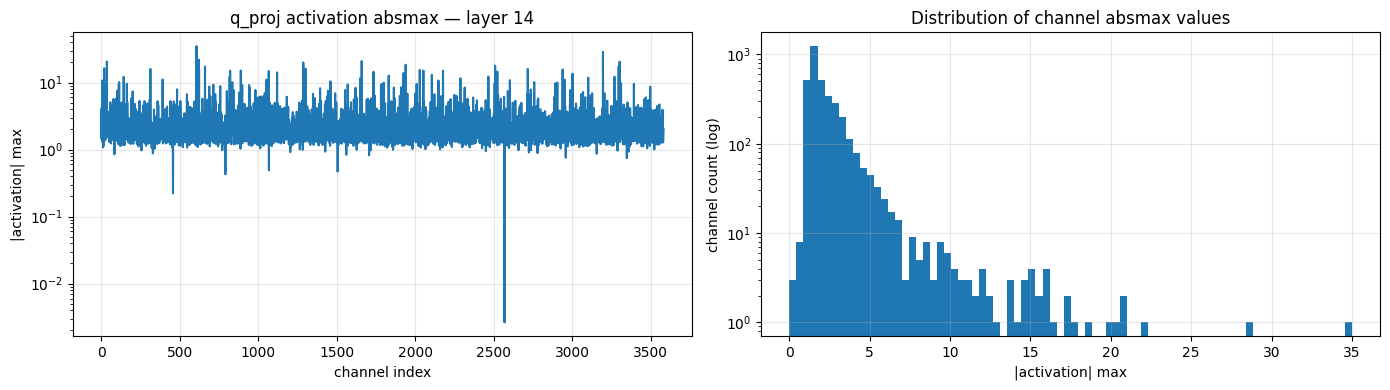


Top-5 outlier channels in layer 14 q_proj:
  channel   608: 35.000
  channel  3197: 28.750
  channel   622: 22.000
  channel  1660: 21.000
  channel    37: 20.625
Median channel value: 1.766
Ratio top-1 / median: 19.8x


In [12]:
# Check 2: outlier distribution — pick a mid-stack layer and show the
# per-channel absmax for q_proj. If the paper's premise holds, we should
# see a few channels dominating.

import matplotlib.pyplot as plt

sample_layer = cfg.num_hidden_layers // 2
sample_key = f'model.layers.{sample_layer}.self_attn.q_proj'
scales = act_scales[sample_key].float().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(scales)
ax1.set_xlabel('channel index')
ax1.set_ylabel('|activation| max')
ax1.set_title(f'q_proj activation absmax — layer {sample_layer}')
ax1.set_yscale('log')
ax1.grid(alpha=0.3)

ax2.hist(scales, bins=80, log=True)
ax2.set_xlabel('|activation| max')
ax2.set_ylabel('channel count (log)')
ax2.set_title('Distribution of channel absmax values')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/activation_outliers_qkv.png', dpi=120, bbox_inches='tight')
plt.show()

top5 = scales.argsort()[-5:][::-1]
print(f'\nTop-5 outlier channels in layer {sample_layer} q_proj:')
for idx in top5:
    print(f'  channel {idx:5d}: {scales[idx]:.3f}')
print(f'Median channel value: {sorted(scales)[len(scales)//2]:.3f}')
print(f'Ratio top-1 / median: {scales.max() / sorted(scales)[len(scales)//2]:.1f}x')

In [13]:
# Check 3: shape consistency
import torch.nn as nn
mismatches = []
for name, module in model.named_modules():
    if not isinstance(module, nn.Linear):
        continue
    if name not in act_scales:
        mismatches.append((name, 'MISSING'))
        continue
    expected = module.in_features
    got = act_scales[name].numel()
    if expected != got:
        mismatches.append((name, f'expected {expected}, got {got}'))

if mismatches:
    print('FAILURES:')
    for n, msg in mismatches[:10]:
        print(f'  {n}: {msg}')
else:
    print(f'All {len(act_scales)} act_scales have correct shapes.')

All 197 act_scales have correct shapes.


## Section 5 — Save summary statistics for the report

The report will want concrete numbers about activation outliers. Save them alongside the scales so notebook 06 (profiling) can reuse them.

In [14]:
import json

# For each Linear type, compute the mean outlier ratio across all layers.
# Outlier ratio = max(|x|) / median(|x|) per channel.
proj_types = ['q_proj', 'k_proj', 'v_proj', 'o_proj',
              'gate_proj', 'up_proj', 'down_proj']
summary = {}
for pt in proj_types:
    ratios = []
    for name, vec in act_scales.items():
        if name.endswith('.' + pt):
            v = vec.float().numpy()
            med = sorted(v)[len(v) // 2]
            if med > 0:
                ratios.append(float(v.max() / med))
    summary[pt] = {
        'num_layers_calibrated': len(ratios),
        'mean_outlier_ratio': sum(ratios) / len(ratios) if ratios else 0.0,
        'max_outlier_ratio' : max(ratios) if ratios else 0.0,
    }

print(json.dumps(summary, indent=2))

os.makedirs('results', exist_ok=True)
with open(f'results/outlier_summary_{SIZE}.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'\nSaved summary to results/outlier_summary_{SIZE}.json')

{
  "q_proj": {
    "num_layers_calibrated": 28,
    "mean_outlier_ratio": 18.30935137612479,
    "max_outlier_ratio": 48.28571319580078
  },
  "k_proj": {
    "num_layers_calibrated": 28,
    "mean_outlier_ratio": 18.30935137612479,
    "max_outlier_ratio": 48.28571319580078
  },
  "v_proj": {
    "num_layers_calibrated": 28,
    "mean_outlier_ratio": 18.30935137612479,
    "max_outlier_ratio": 48.28571319580078
  },
  "o_proj": {
    "num_layers_calibrated": 28,
    "mean_outlier_ratio": 2.9635663543428694,
    "max_outlier_ratio": 4.418604850769043
  },
  "gate_proj": {
    "num_layers_calibrated": 28,
    "mean_outlier_ratio": 13.259937950542994,
    "max_outlier_ratio": 29.677419662475586
  },
  "up_proj": {
    "num_layers_calibrated": 28,
    "mean_outlier_ratio": 13.259937950542994,
    "max_outlier_ratio": 29.677419662475586
  },
  "down_proj": {
    "num_layers_calibrated": 28,
    "mean_outlier_ratio": 13.236415914126805,
    "max_outlier_ratio": 72.1066665649414
  }
}

Save

## Done!

### What you should see if this worked correctly

- **Top-1 / median ratio** in the tens to hundreds for `q_proj`, `k_proj`, `v_proj`, `gate_proj`, `up_proj`. This is the activation-outlier phenomenon the paper identifies.
- **Low outlier ratio** (maybe 2-5x) for `o_proj` and `down_proj` — these take already-processed activations and have less pathological distributions.
- **512 samples** is enough to stabilize the per-channel max within a few percent. You can verify by re-running with 256 samples and comparing.

### Next

→ `02_smooth_and_fakequant.ipynb` — applies the scales we just computed to produce a smoothed model, then W8A8-fake-quantizes it. Measures perplexity on WikiText to verify accuracy is preserved before we spend time on the full code benchmarks.

### Troubleshooting

- **OOM during calibration:** drop `SEQ_LEN` to 256, or use `device_map='auto'` with some layers on CPU (much slower).
- **Pile dataset not downloading:** if `mit-han-lab/pile-val-backup` is gated, try `'NeelNanda/pile-10k'` or `'cerebras/SlimPajama-627B'` (streaming).
- **Calibration only found `N < expected` Linears:** check whether the tokenizer's chat template is adding something unexpected, or whether the model is actually Qwen2 (not Qwen2-VL or Qwen-MoE).
- **Scales are identical across layers:** bug — the hooks probably failed. Check that all hooks in the `finally` block are being removed correctly.